# Social Doors Representational Similarity Analysis

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltools.data import Brain_Data, Adjacency
from nltools.mask import expand_mask
from nltools.stats import fdr, threshold, fisher_r_to_z, one_sample_permutation
from sklearn.metrics import pairwise_distances
from nilearn.plotting import plot_glass_brain, plot_stat_map

import warnings
warnings.filterwarnings('ignore')

In [2]:
#bids_dir = '/data/projects/social_doors/'
bids_dir = '/Volumes/HP-SOC-DOOR/social_doors/'

os.chdir(bids_dir)

outp_dir = os.path.join(bids_dir, 'derivatives', 'rsa-bw_runs-fb_only')
data_dir = os.path.join(bids_dir, 'derivatives','social_doors-nilearn-indiv_runs')

if os.path.exists(outp_dir):
    print('Output directory already exists. Continuing will overwrite data.')
else:
    os.makedirs(outp_dir)

Output directory already exists. Continuing will overwrite data.


In [3]:
subjs_scan_info = pd.read_csv(bids_dir+'derivatives/participants_good.tsv', sep='\t', 
                              index_col=0)

subjs_list = list(subjs_scan_info['participant_id'].unique())
len(subjs_list)

subjs_list.sort()
subjs_list.remove('sub-3880')
subjs_list.remove('sub-4069')
print('Found '+str(len(subjs_list))+' subjects')
subj = subjs_list[0]

file_list = glob.glob(os.path.join(data_dir, subj, f'zmap*.nii'))
file_list.sort()
#file_list = file_list[:-2]
print('Found '+str(len(file_list))+' zmaps maps for '+subj)

#conditions = [os.path.basename(x)[:-7].split('beta_')[-1] for x in file_list]

#beta = Brain_Data(file_list)

Found 61 subjects
Found 24 zmaps maps for sub-010


In [4]:
print(subjs_list)

['sub-010', 'sub-013', 'sub-028', 'sub-036', 'sub-3845', 'sub-3846', 'sub-3848', 'sub-3849', 'sub-3852', 'sub-3855', 'sub-3864', 'sub-3865', 'sub-3874', 'sub-3883', 'sub-3886', 'sub-3887', 'sub-3890', 'sub-3892', 'sub-3893', 'sub-3895', 'sub-3912', 'sub-3920', 'sub-3967', 'sub-3989', 'sub-4011', 'sub-4017', 'sub-4018', 'sub-4019', 'sub-4020', 'sub-5049', 'sub-5051', 'sub-5054', 'sub-5058', 'sub-5064', 'sub-5067', 'sub-5068', 'sub-5082', 'sub-5083', 'sub-5084', 'sub-5085', 'sub-5090', 'sub-5091', 'sub-5092', 'sub-5093', 'sub-5094', 'sub-5095', 'sub-5098', 'sub-5102', 'sub-5108', 'sub-5125', 'sub-5126', 'sub-5130', 'sub-5131', 'sub-5133', 'sub-5136', 'sub-5140', 'sub-5145', 'sub-6003', 'sub-6004', 'sub-6005', 'sub-6006']


In [5]:
subjs_scan_info.head()

,participant_id,age,sex,group
0,sub-010,13,F,kid
2,sub-013,13,M,kid
5,sub-028,15,M,kid
6,sub-036,16,F,kid
7,sub-5049,12,F,kid


In [6]:
conditions = ['negative_win','negative_loss',
              'positive_win','positive_loss']

condition_labels = [x+'-mdoors' for x in conditions] + [x+'-social' for x in conditions]

# Hypothesis RDMs

## Localization of monterary and social reward processing
### Hypothesis
The cerebellum will process monetary and social reward processing in separate regions within the cerebellum. These regions will be sensitive to the valence of each domain.

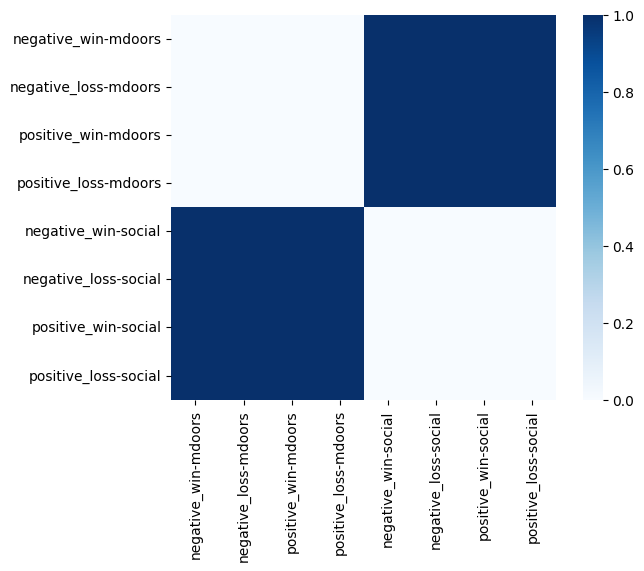

In [7]:
tdomain_df = pd.DataFrame([[0,0,0,0,1,1,1,1],
                           [0,0,0,0,1,1,1,1],
                           [0,0,0,0,1,1,1,1],
                           [0,0,0,0,1,1,1,1],
                           [1,1,1,1,0,0,0,0],
                           [1,1,1,1,0,0,0,0],
                           [1,1,1,1,0,0,0,0],
                           [1,1,1,1,0,0,0,0]],
                         index=condition_labels, columns=condition_labels)

tdomain_adj = Adjacency(tdomain_df, matrix_type='distance', labels=condition_labels)
f = tdomain_adj.plot(cmap=sns.color_palette("Blues", as_cmap=True))

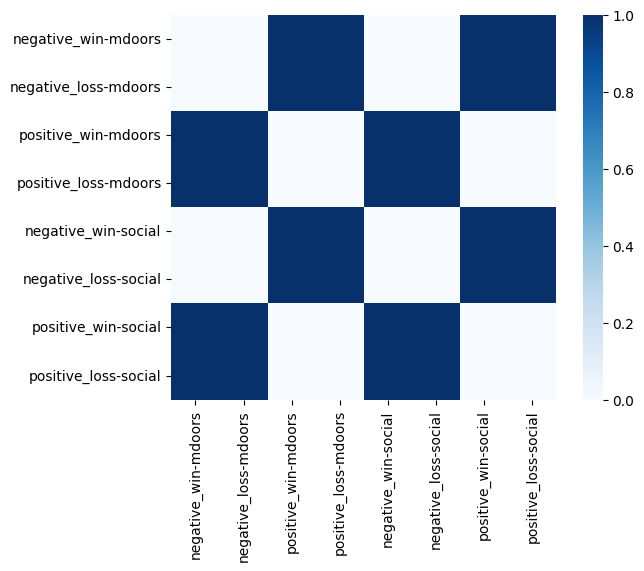

In [8]:
valence_df = pd.DataFrame([[0,0,1,1,0,0,1,1],
                           [0,0,1,1,0,0,1,1],
                           [1,1,0,0,1,1,0,0],
                           [1,1,0,0,1,1,0,0],
                           [0,0,1,1,0,0,1,1],
                           [0,0,1,1,0,0,1,1],
                           [1,1,0,0,1,1,0,0],
                           [1,1,0,0,1,1,0,0]],
                         index=condition_labels, columns=condition_labels)

valence_adj = Adjacency(valence_df, matrix_type='distance', labels=condition_labels)
f = valence_adj.plot(cmap=sns.color_palette("Blues", as_cmap=True))

The next RDM will be sensitive to outcome. Wins are wins and losses are losses. 

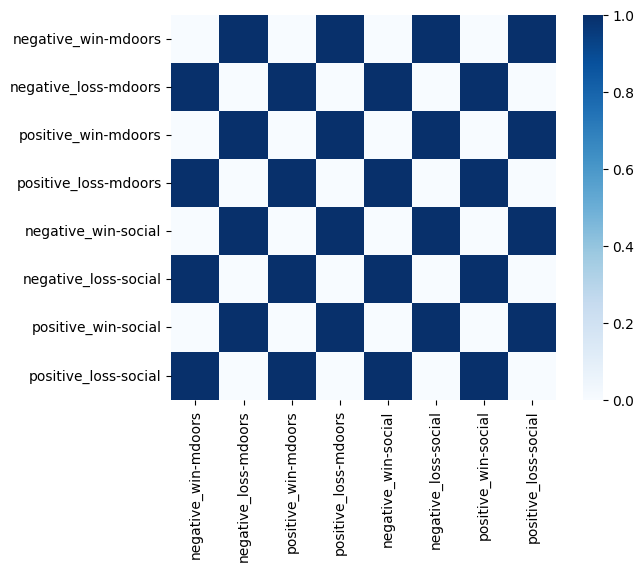

In [9]:
outcome_df = pd.DataFrame([[0,1,0,1,0,1,0,1],
                           [1,0,1,0,1,0,1,0],
                           [0,1,0,1,0,1,0,1],
                           [1,0,1,0,1,0,1,0],
                           [0,1,0,1,0,1,0,1],
                           [1,0,1,0,1,0,1,0],
                           [0,1,0,1,0,1,0,1],
                           [1,0,1,0,1,0,1,0]],
                         index=condition_labels, columns=condition_labels)

outcome_adj = Adjacency(outcome_df, matrix_type='distance', labels=condition_labels)
f = outcome_adj.plot(cmap=sns.color_palette("Blues", as_cmap=True))

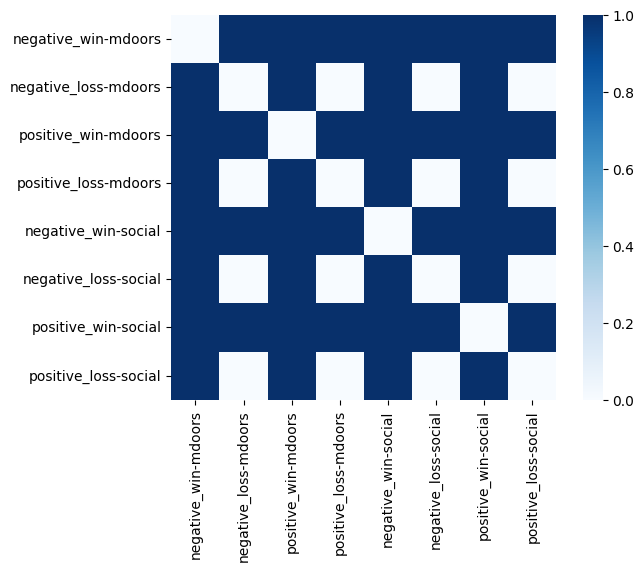

In [10]:
crctval_df = pd.DataFrame([[1,1,1,1,1,1,1,1],
                           [1,0,1,0,1,0,1,0],
                           [1,1,1,1,1,1,1,1],
                           [1,0,1,0,1,0,1,0],
                           [1,1,1,1,1,1,1,1],
                           [1,0,1,0,1,0,1,0],
                           [1,1,1,1,1,1,1,1],
                           [1,0,1,0,1,0,1,0]],
                         index=condition_labels, columns=condition_labels)

crctval_adj = Adjacency(crctval_df, matrix_type='distance', labels=condition_labels)
f = crctval_adj.plot(cmap=sns.color_palette("Blues", as_cmap=True))

The last RDM is an interaction RDM between valence and outcome. Trials that share no features will be a 1, trials that share a single feature will be a 0.5, and trials that share all features will be a 0.

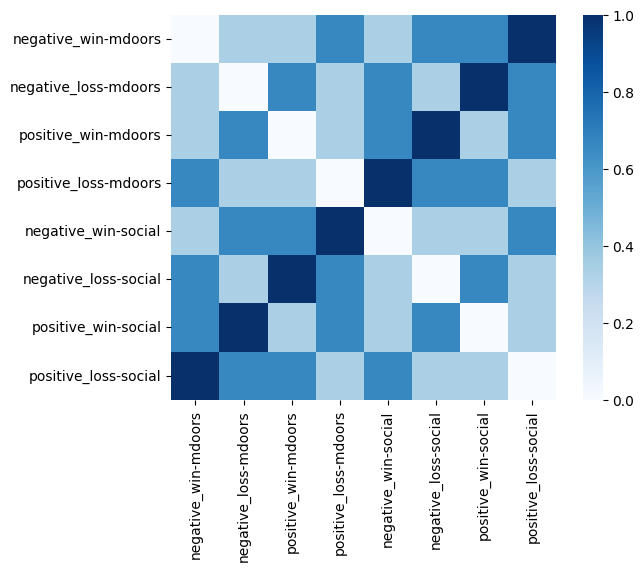

In [11]:
intract_df = pd.DataFrame([[0/3, 1/3, 1/3, 2/3, 1/3, 2/3, 2/3, 3/3],
                           [1/3, 0/3, 2/3, 1/3, 2/3, 1/3, 3/3, 2/3],
                           [1/3, 2/3, 0/3, 1/3, 2/3, 3/3, 1/3, 2/3],
                           [2/3, 1/3, 1/3, 0/3, 3/3, 2/3, 2/3, 1/3],
                           [1/3, 2/3, 2/3, 3/3, 0/3, 1/3, 1/3, 2/3],
                           [2/3, 1/3, 3/3, 2/3, 1/3, 0/3, 2/3, 1/3],
                           [2/3, 3/3, 1/3, 2/3, 1/3, 2/3, 0/3, 1/3],
                           [3/3, 2/3, 2/3, 1/3, 2/3, 1/3, 1/3, 0/3]],
                         index=condition_labels, columns=condition_labels)

intract_adj = Adjacency(intract_df, matrix_type='distance', labels=condition_labels)
f = intract_adj.plot(cmap=sns.color_palette("Blues", as_cmap=True))

# Reward Processing

In [12]:
# Import ROIs
reward_roi_list = glob.glob(os.path.join(bids_dir,'derivatives','rois', f'roi_bin_reward_*.nii.gz'))
reward_roi_names = [os.path.basename(x)[:-7].split('roi_bin_reward_')[-1] for x in reward_roi_list]

reward_roi_dict = dict(zip(reward_roi_names, reward_roi_list))


print(reward_roi_dict)


{'VS_l': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_reward_VS_l.nii.gz', 'VS_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_reward_VS_r.nii.gz', 'vmPFC_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_reward_vmPFC_b.nii.gz'}


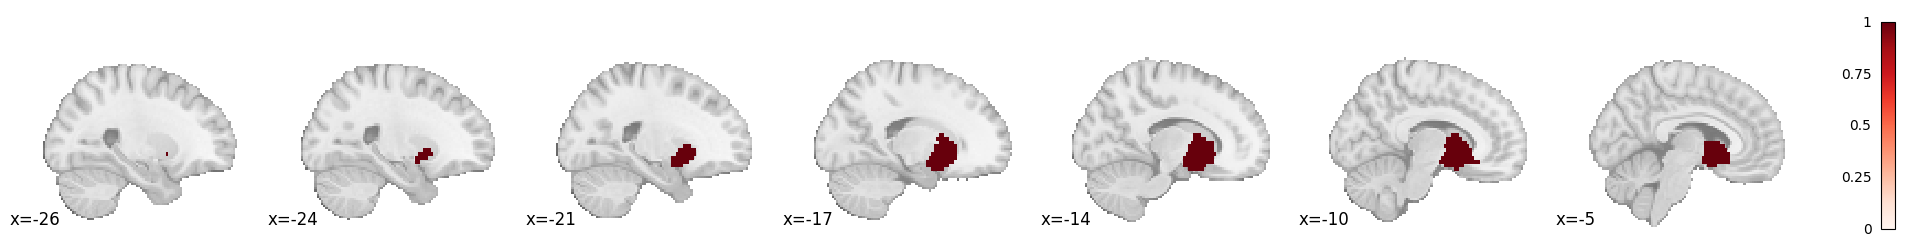

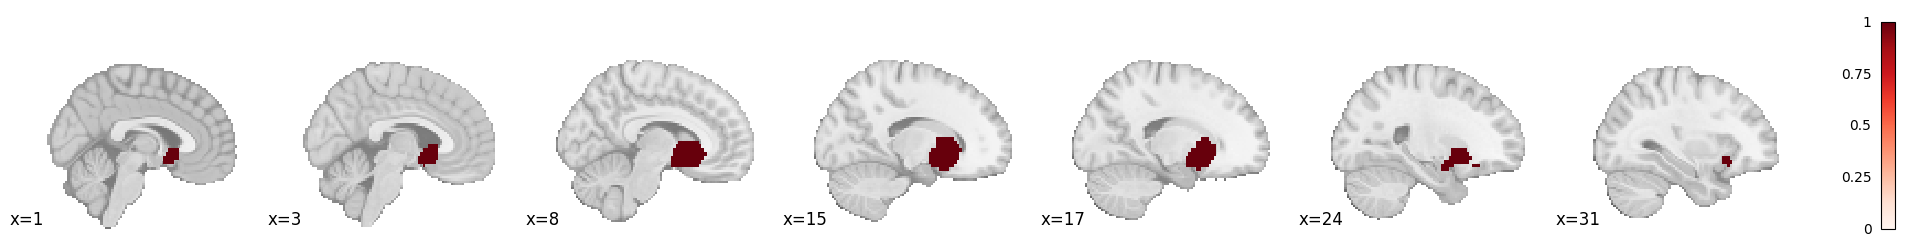

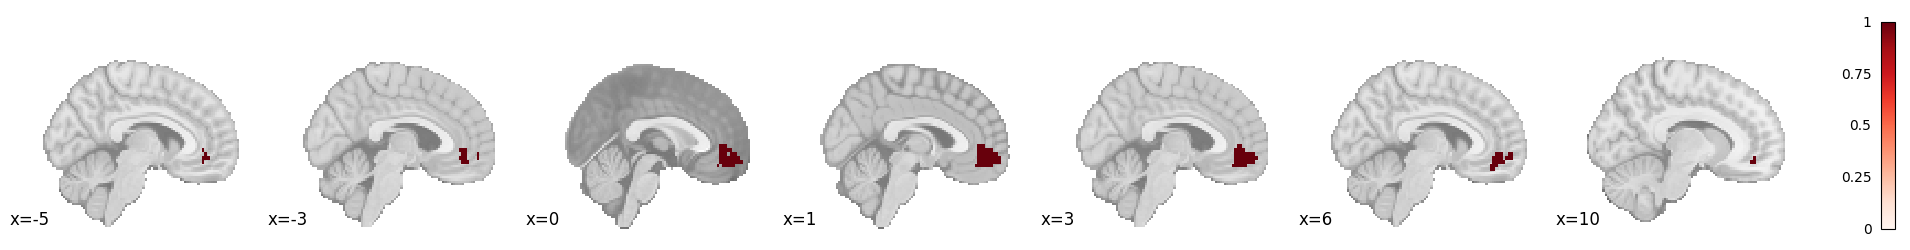

In [13]:
# Import ROIs
for n in range(len(reward_roi_names)):
    temp_roi = Brain_Data(reward_roi_list[n], mask=reward_roi_list[n])
    
    plot_stat_map(temp_roi.to_nifti(), 
                 display_mode='x',
                 cmap='Reds')

In [14]:
# Import ROIs
striat_roi_list = glob.glob(os.path.join(bids_dir,'derivatives','rois', f'striatum_*.nii.gz'))
striat_roi_names = [os.path.basename(x)[:-7].split('rois/')[-1] for x in striat_roi_list]

striat_roi_dict = dict(zip(striat_roi_names, striat_roi_list))


print(striat_roi_dict)

{'striatum_dorsala': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/striatum_dorsala.nii.gz', 'striatum_dorsalp': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/striatum_dorsalp.nii.gz', 'striatum_ventral': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/striatum_ventral.nii.gz'}


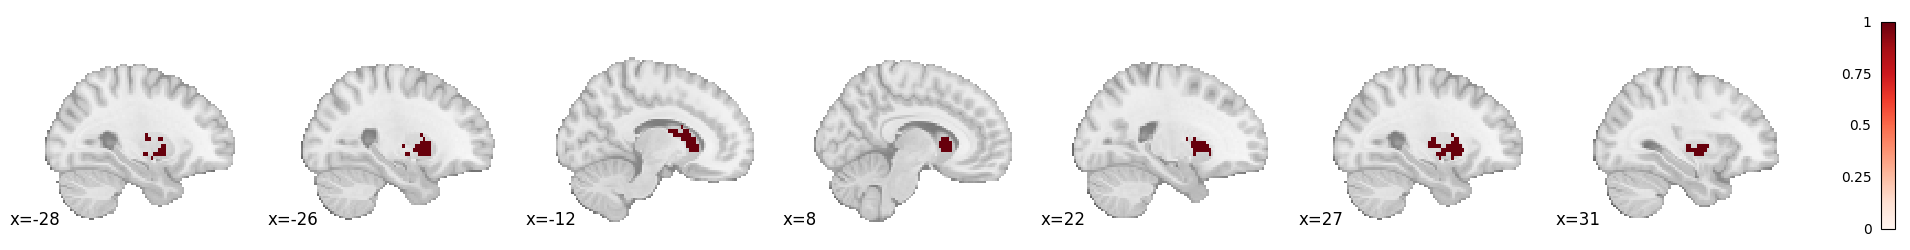

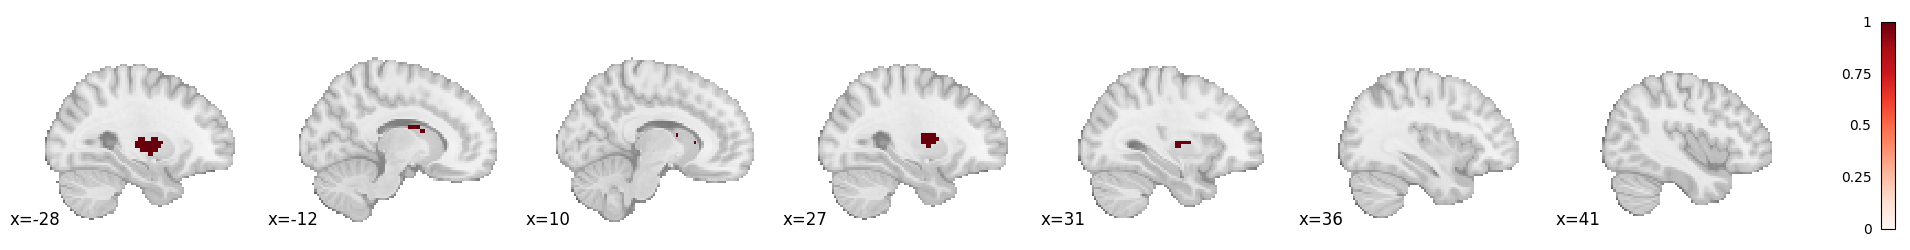

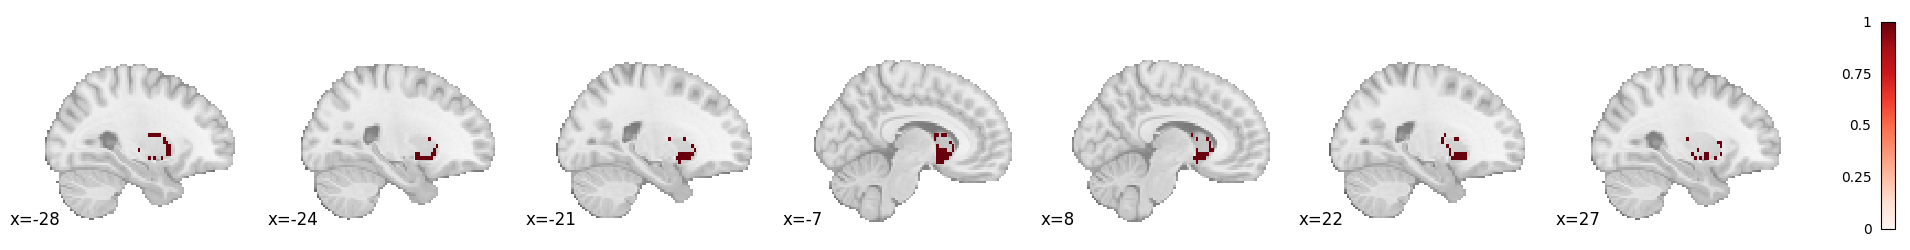

In [15]:
# Import ROIs
for n in range(len(striat_roi_names)):
    temp_roi = Brain_Data(striat_roi_list[n], mask=striat_roi_list[n])
    
    plot_stat_map(temp_roi.to_nifti(), 
                 display_mode='x',
                 cmap='Reds')

In [16]:
# Import ROIs
social_roi_list = glob.glob(os.path.join(bids_dir,'derivatives','rois', f'roi_bin_social_*.nii.gz'))
social_roi_names = [os.path.basename(x)[:-7].split('roi_bin_social_')[-1] for x in social_roi_list]

social_roi_dict = dict(zip(social_roi_names, social_roi_list))


print(social_roi_dict)

{'AMG_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_AMG_r.nii.gz', 'ATL_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_ATL_b.nii.gz', 'ATL_l': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_ATL_l.nii.gz', 'ATL_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_ATL_r.nii.gz', 'C1_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_C1_r.nii.gz', 'PCC_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_PCC_b.nii.gz', 'TPJ_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_TPJ_b.nii.gz', 'TPJ_l': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_TPJ_l.nii.gz', 'TPJ_r': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_TPJ_r.nii.gz', 'dmPFC_b': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/roi_bin_social_dmPFC_b.nii.gz'}


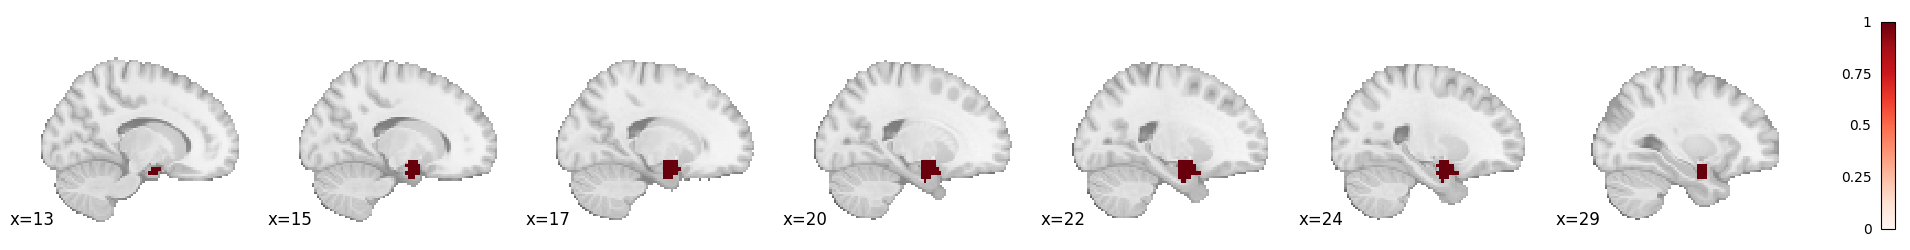

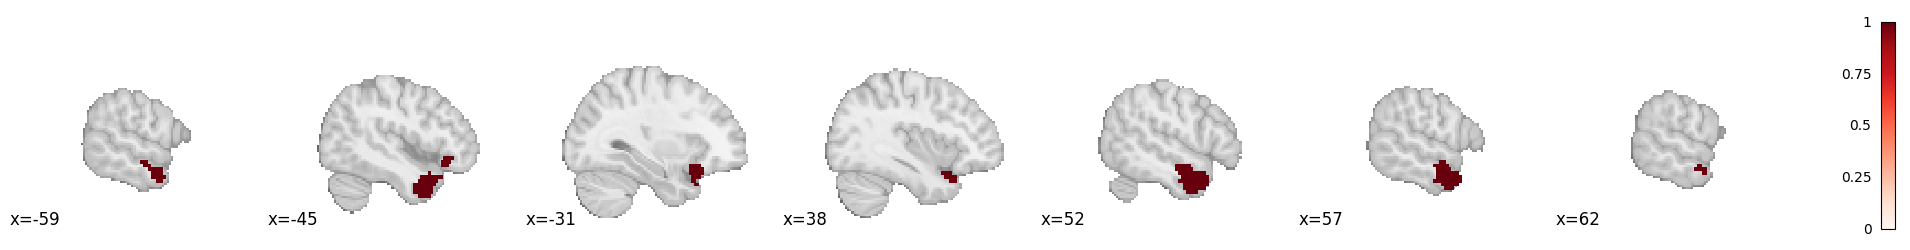

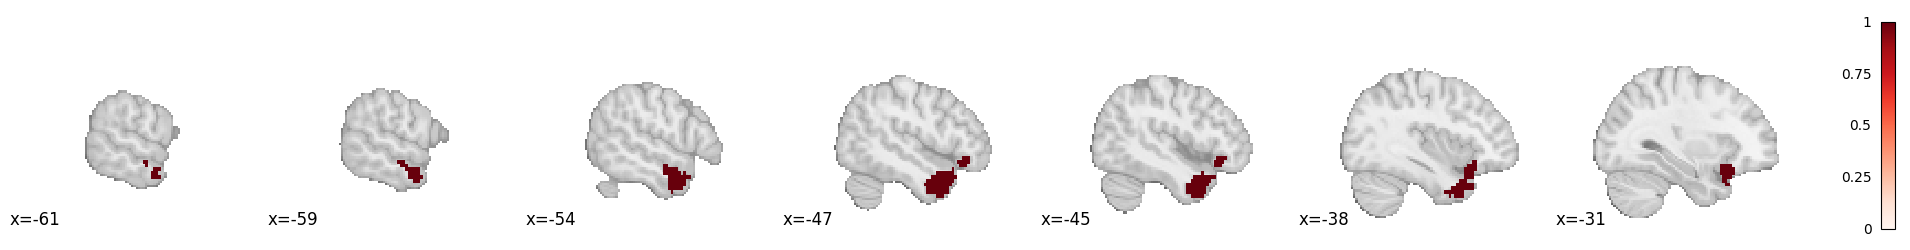

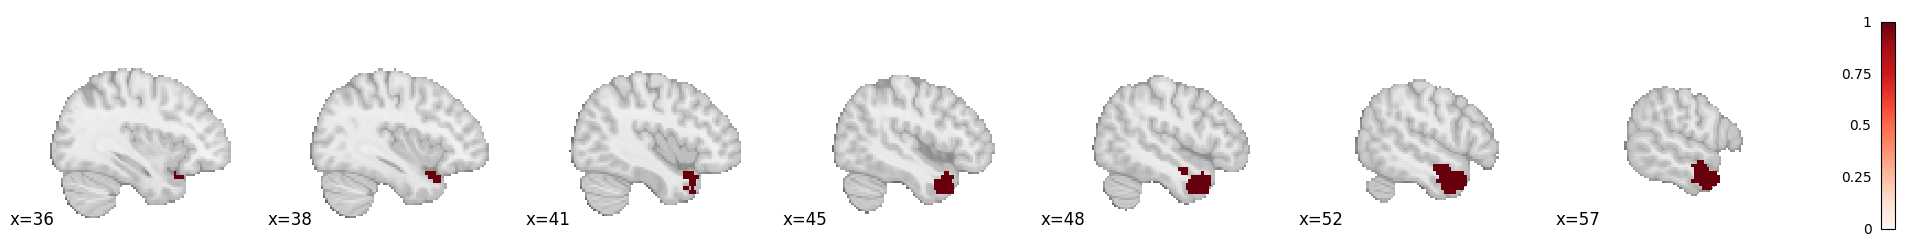

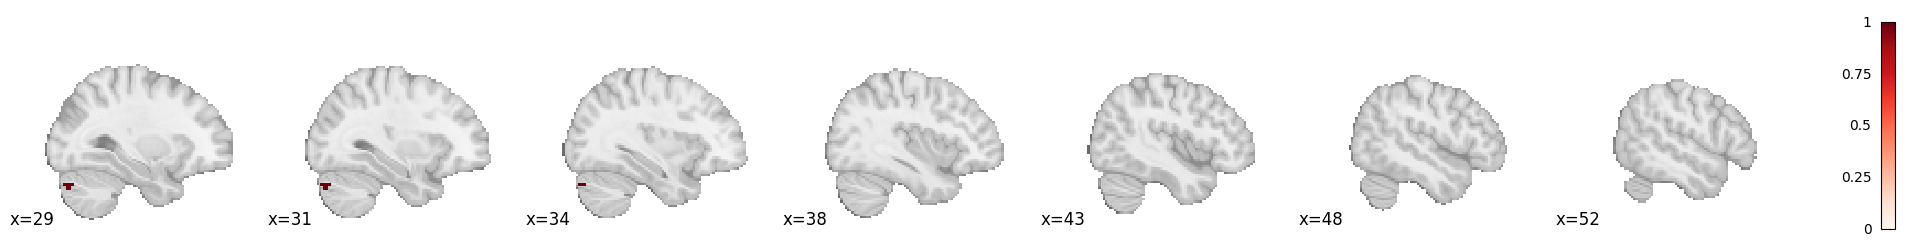

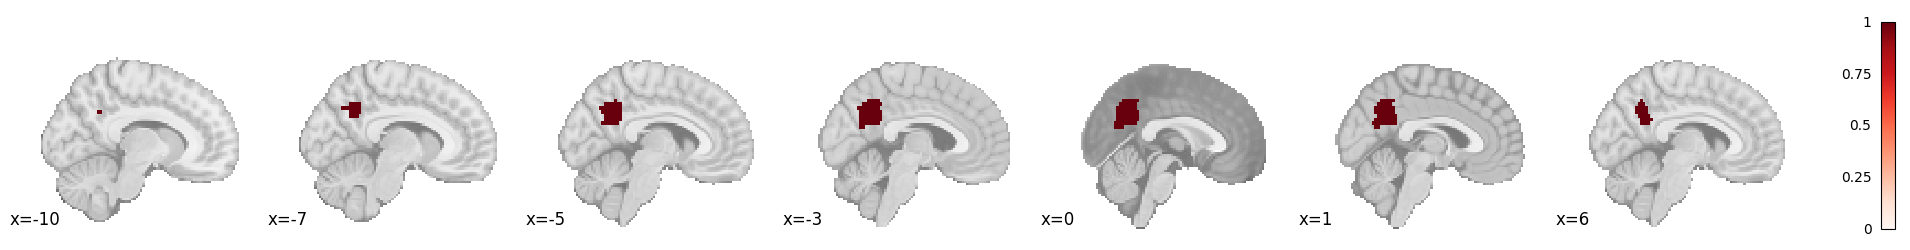

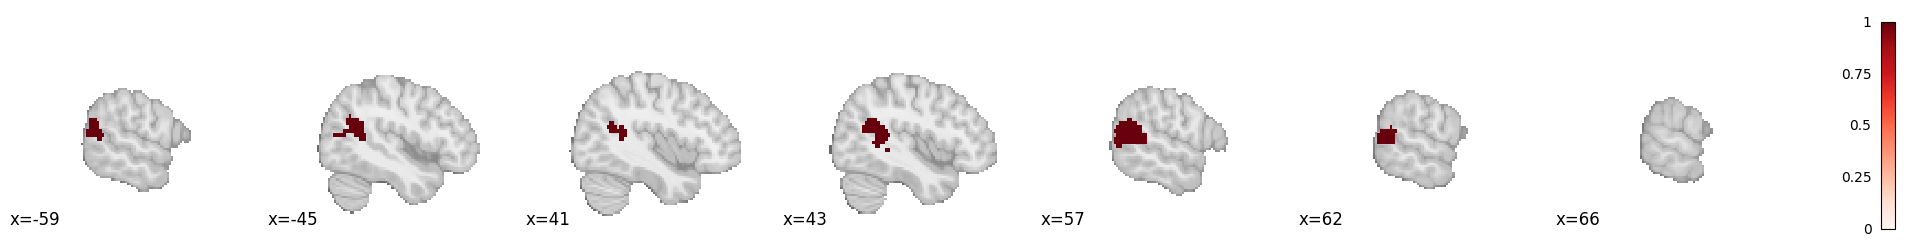

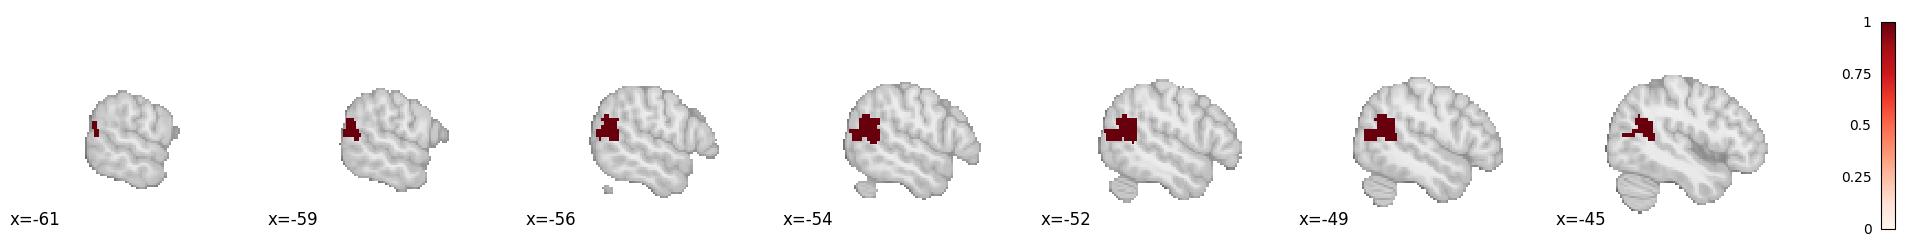

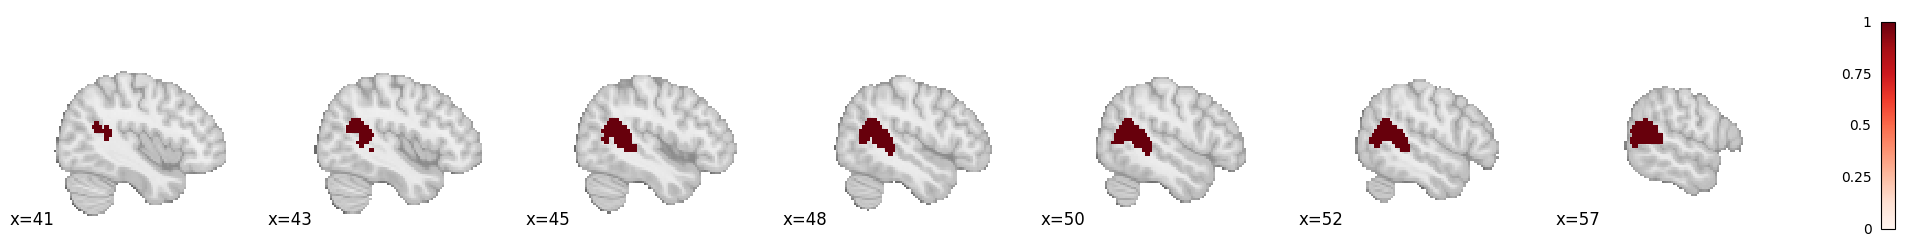

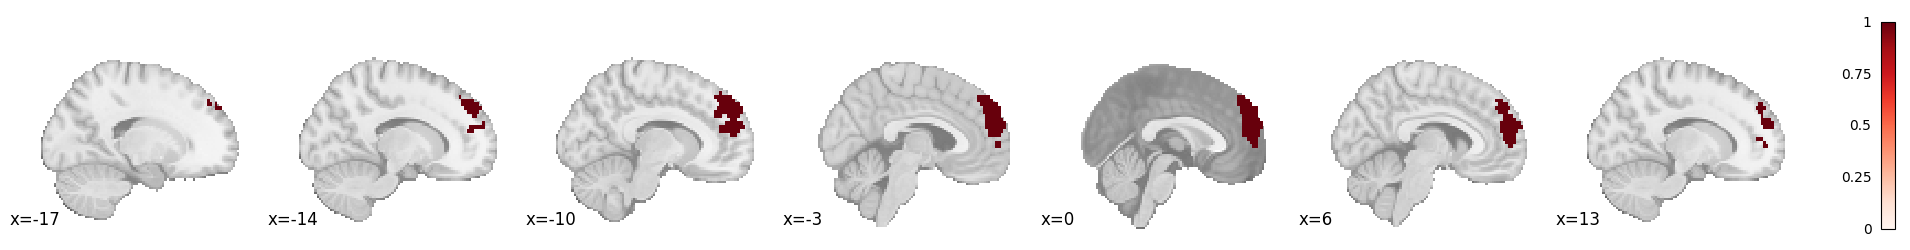

In [17]:
# Import ROIs
for n in range(len(social_roi_names)):
    temp_roi = Brain_Data(social_roi_list[n], mask=social_roi_list[n])
    
    plot_stat_map(temp_roi.to_nifti(), 
                 display_mode='x',
                 cmap='Reds')

In [18]:
# Import ROIs
mdtbcb_roi_list = glob.glob(os.path.join(bids_dir,'derivatives','rois', f'mdtb_*.nii.gz'))
mdtbcb_roi_names = [os.path.basename(x)[:-7].split('mdtb_')[-1] for x in mdtbcb_roi_list]

mdtbcb_roi_dict = dict(zip(mdtbcb_roi_names, mdtbcb_roi_list))


print(mdtbcb_roi_dict)

{'region01': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region01.nii.gz', 'region02': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region02.nii.gz', 'region03': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region03.nii.gz', 'region04': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region04.nii.gz', 'region05': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region05.nii.gz', 'region06': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region06.nii.gz', 'region07': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region07.nii.gz', 'region08': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region08.nii.gz', 'region09': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region09.nii.gz', 'region10': '/Volumes/HP-SOC-DOOR/social_doors/derivatives/rois/mdtb_region10.nii.gz'}


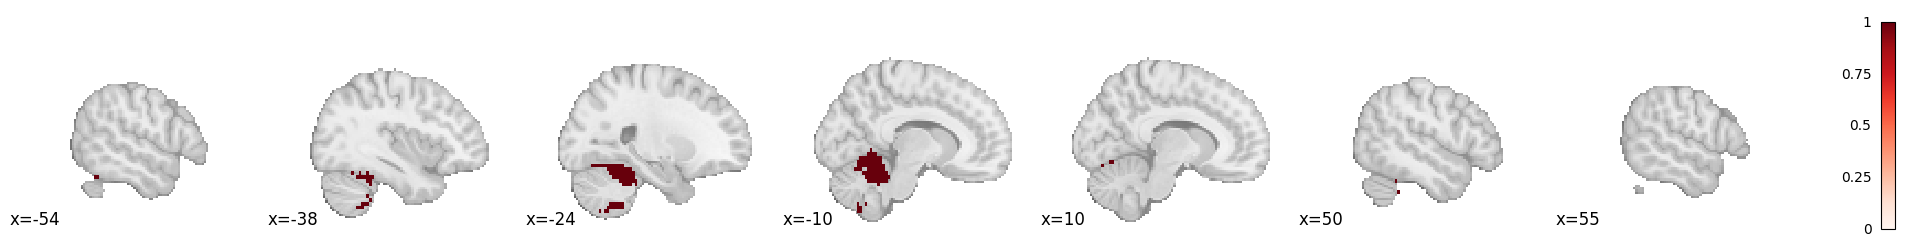

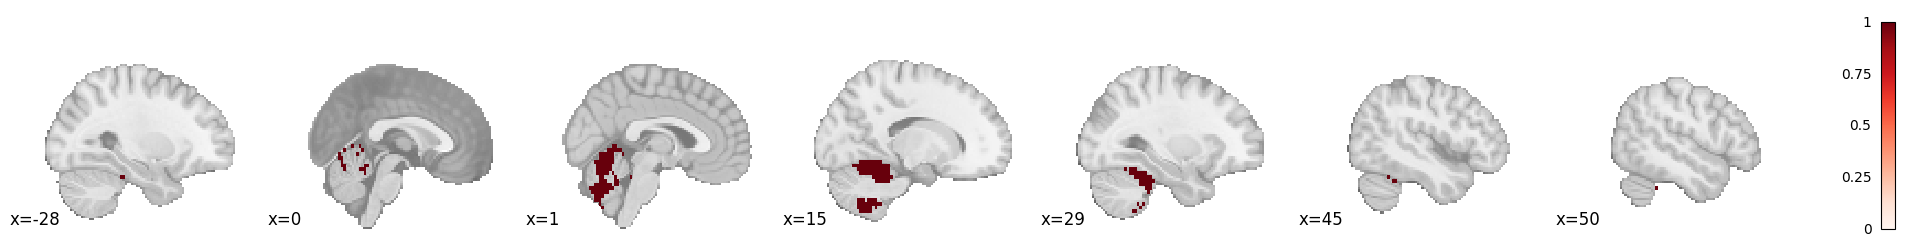

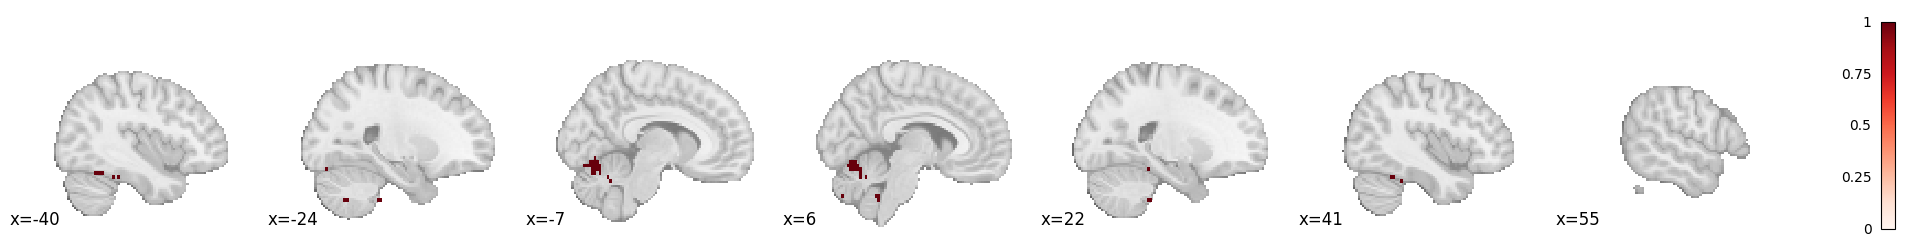

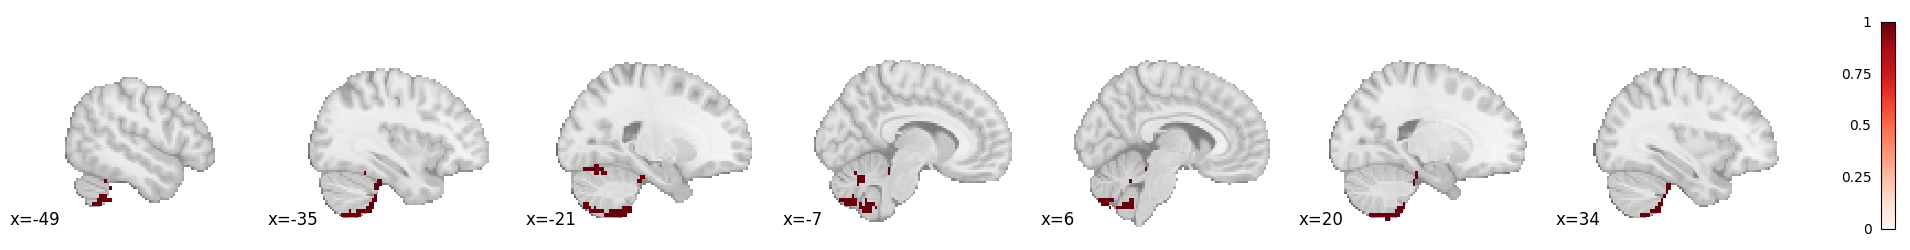

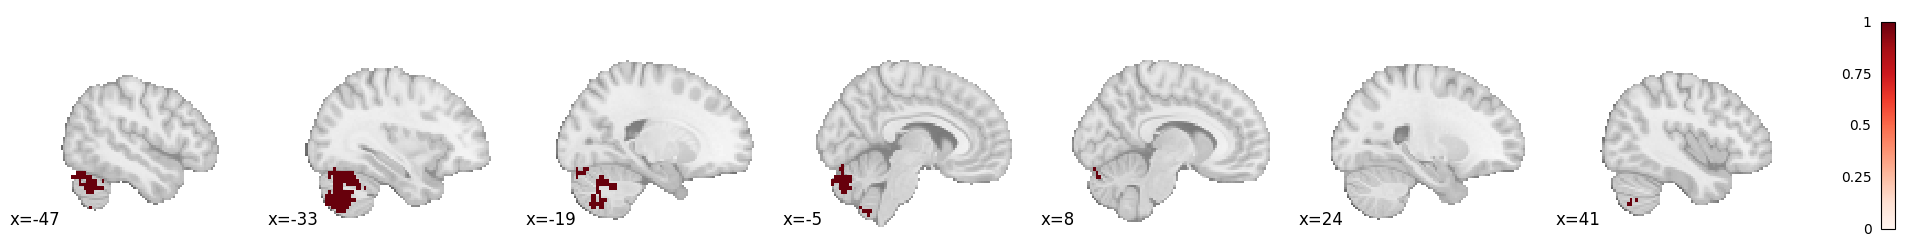

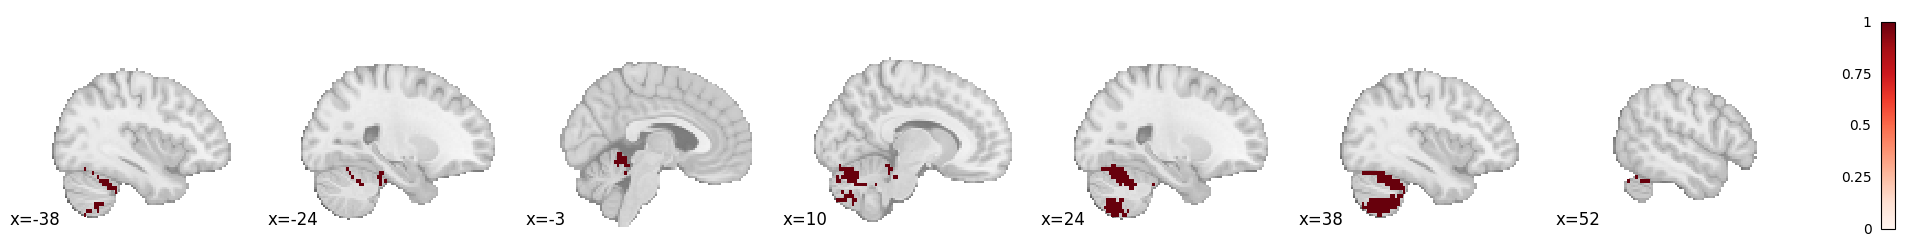

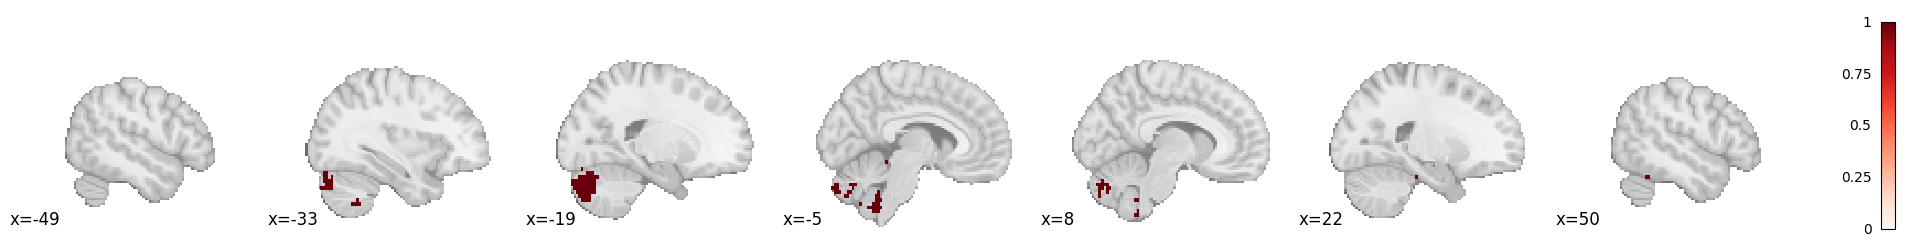

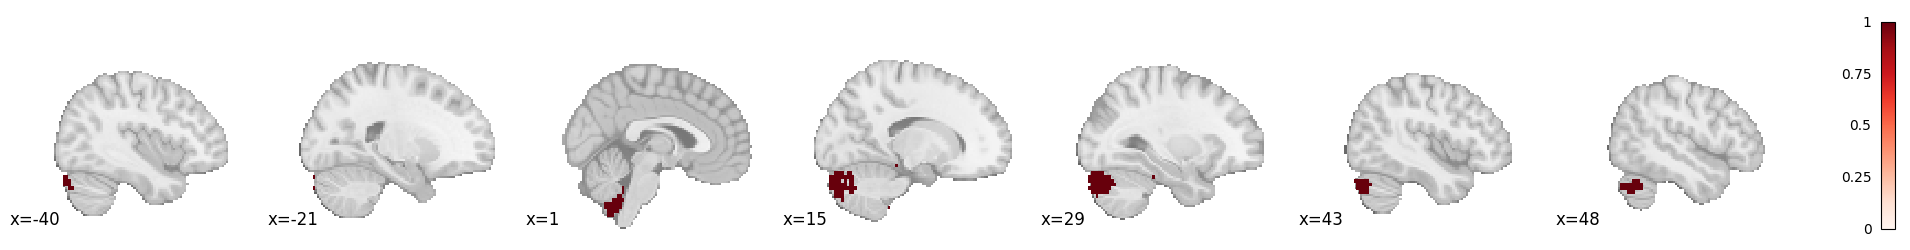

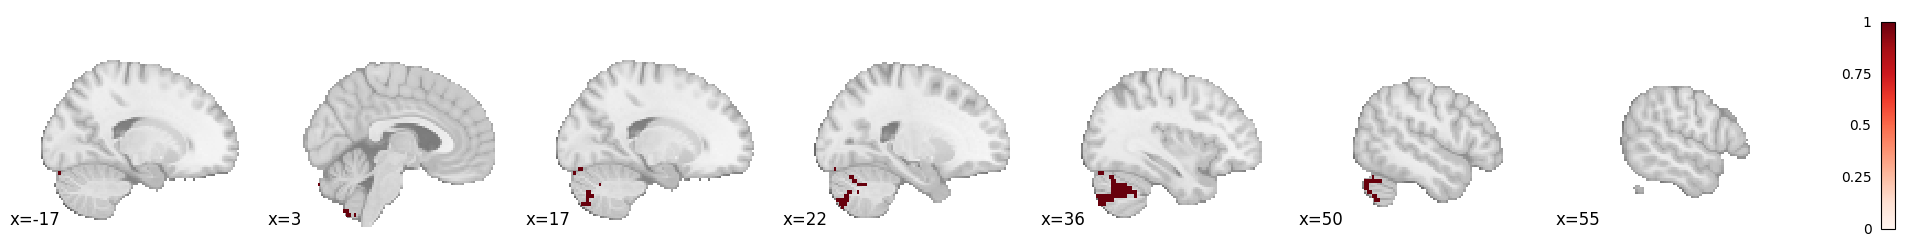

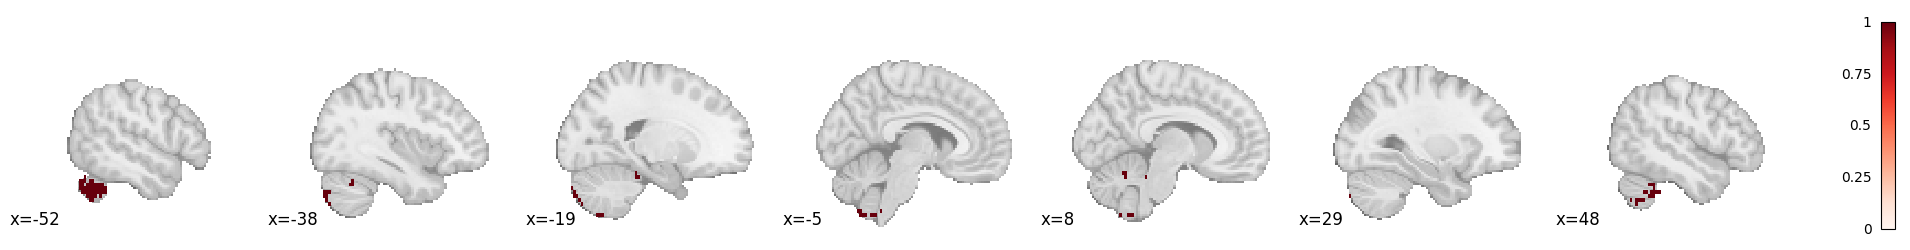

In [19]:
# Import ROIs
for n in range(len(mdtbcb_roi_names)):
    temp_roi = Brain_Data(mdtbcb_roi_list[n], mask=mdtbcb_roi_list[n])
    
    plot_stat_map(temp_roi.to_nifti(), 
                 display_mode='x',
                 cmap='Reds')

## Hypothesis
**The vmPFC will be sensitive to the valence of trials**

In [20]:
tasks = ['mdoors', 'social']

subj_t1 = os.path.join(bids_dir, 'derivatives', 'fmriprep', subj, 'anat',
                       subj+'_space-MNI152NLin2009cAsym_label-GM_probseg_bin.nii.gz')

func_files = []
for n in range(2):
    for task in tasks:
        for cond in conditions:
            temp_file = [x for x in file_list if task+'_'+cond+'_run-'+str(n+1)+'.nii' in x][0]
            func_files.append(temp_file)

func_files


['/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_mdoors_negative_win_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_mdoors_negative_loss_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_mdoors_positive_win_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_mdoors_positive_loss_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_negative_win_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_negative_loss_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_positive_win_run-1.nii',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-010/zmap_social_positive_loss_run-1.ni

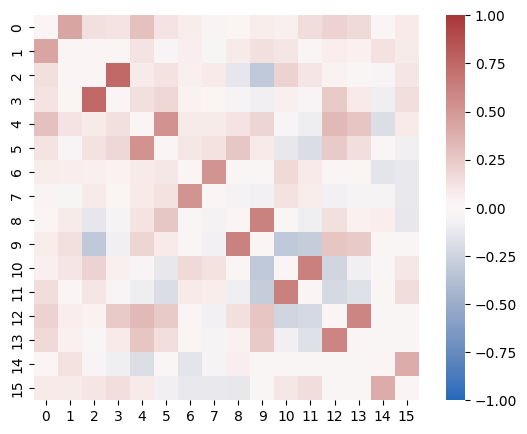

In [21]:
betas = Brain_Data(func_files, mask=subj_t1)

if betas.data.ndim == 1:
    betas.data = betas.data.reshape(len(func_files), -1)

vmPFC_b_mask = Brain_Data(reward_roi_dict['vmPFC_b'], mask=subj_t1)

out = 1 - betas.apply_mask(vmPFC_b_mask).distance(metric='correlation')
#out.labels=condition_labels

f2 = out.plot(vmin=-1, vmax=1, cmap=sns.color_palette('vlag', as_cmap=True))

In [22]:
n_conds = len(condition_labels)

<Axes: >

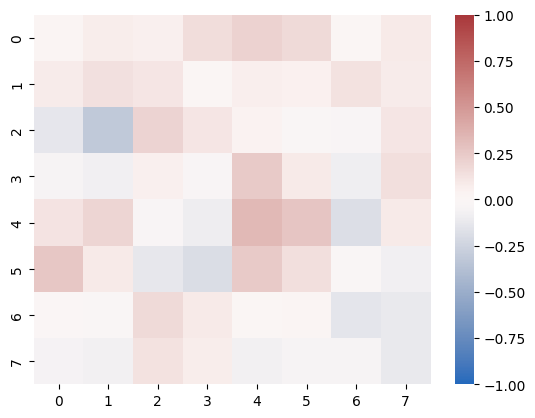

In [23]:
sns.heatmap(out.squareform()[0:n_conds,-n_conds:], 
            vmin=-1, vmax=1, cmap=sns.color_palette('vlag', as_cmap=True))

<Axes: >

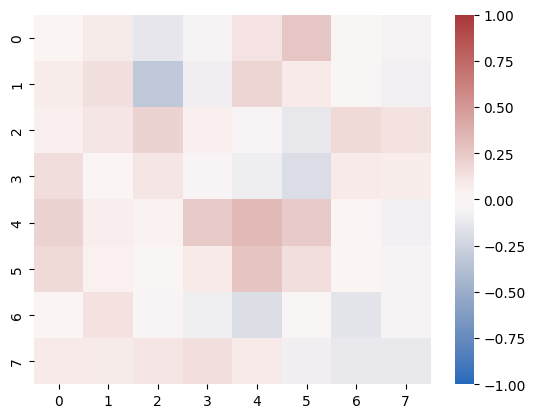

In [24]:
sns.heatmap(out.squareform()[-n_conds:,:n_conds], 
            vmin=-1, vmax=1, cmap=sns.color_palette('vlag', as_cmap=True))

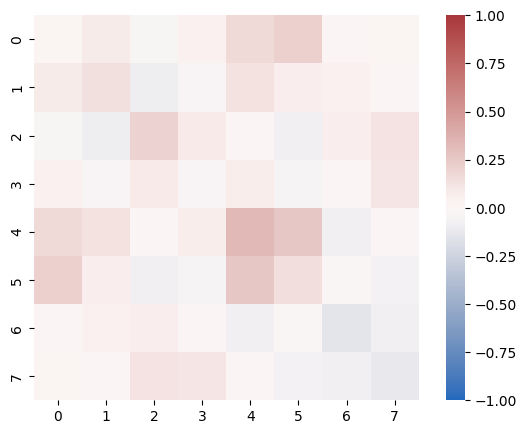

In [25]:
out_avg = Adjacency(out.squareform()[0:n_conds,-n_conds:])
out_avg = out_avg.append(Adjacency(out.squareform()[-n_conds:,0:n_conds]))

out_avg.mean().plot(vmin=-1, vmax=1, cmap=sns.color_palette('vlag', as_cmap=True))

In [26]:
import warnings
warnings.simplefilter("ignore", UserWarning)

In [27]:
rois = list(social_roi_dict.values()) + list(mdtbcb_roi_dict.values()) + list(striat_roi_dict.values())
roi_names = [x + '-social' for x in social_roi_names] + mdtbcb_roi_names + striat_roi_names

In [28]:
from scipy import stats

In [29]:
def upper_tri_indexing(A):
    m = A.shape[0]
    r,c = np.triu_indices(m,1)
    return A[r,c]

In [30]:
tdomain_adj_upr = upper_tri_indexing(tdomain_adj.squareform())
valence_adj_upr = upper_tri_indexing(valence_adj.squareform())
outcome_adj_upr = upper_tri_indexing(outcome_adj.squareform())
crctval_adj_upr = upper_tri_indexing(crctval_adj.squareform())
intract_adj_upr = upper_tri_indexing(intract_adj.squareform())

In [33]:
# Create a dictionary to store the data from each analysis
all_sub_sim = {}

# Create a dictionary item for each ROI
for n in range(len(roi_names)):
    all_sub_sim[roi_names[n]] = Adjacency()

# Create separate dataframes for each RDM's analysis
all_sub_tsk_rsa = pd.DataFrame(columns=['subj','group','roi','r'])
all_sub_val_rsa = pd.DataFrame(columns=['subj','group','roi','r'])
all_sub_out_rsa = pd.DataFrame(columns=['subj','group','roi','r'])
all_sub_cvl_rsa = pd.DataFrame(columns=['subj','group','roi','r'])
all_sub_itr_rsa = pd.DataFrame(columns=['subj','group','roi','r'])

# Create a list of rois and the ROI names
rois = list(social_roi_dict.values()) + list(mdtbcb_roi_dict.values()) + list(striat_roi_dict.values())
roi_names = [x + '-social' for x in social_roi_names] + mdtbcb_roi_names + striat_roi_names





for subj in subjs_list:
    if subj in list(all_sub_tsk_rsa['subj']):
        continue
    
    # Find the list of z-scored beta maps
    file_list = glob.glob(os.path.join(data_dir, subj, f'zmap*.nii.gz'))
    file_list.sort()
    
    
    # Find the group ID for the participant
    group_id = subjs_scan_info[subjs_scan_info['participant_id'] == subj]['group'].iloc[0]
    
    print('Calculating similarities for '+subj)
    
        
    # Find the subject brain mask
    subj_t1 = os.path.join(bids_dir, 'derivatives', 'fmriprep', subj, 'anat',
                            subj+'_space-MNI152NLin2009cAsym_label-GM_probseg_bin.nii.gz')
        
    # Find the SUIT cerbellum mask
    subj_cb = bids_dir+'derivatives/fmriprep/'+subj+'/anat/'+subj+'_run-1_space-MNI152NLin2009cAsym_desc-preproc_T1w_cerebellum_dseg.nii.gz'
        
    # Check if there are four task runs
    raw_runs = glob.glob(os.path.join('derivatives','fmriprep',subj,'func',
                                        subj+f'_task-*_run-*_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'))
        
    if len(raw_runs) < 4:
        continue
    else:
        
        func_files = []
        suit_files = []
        for n in range(2):
            for task in ['mdoors', 'social']:
                for cond in conditions:
                    temp_file = [x for x in file_list if task+'_'+cond+'_run-'+str(n+1)+'.nii.gz' in x][0]
                    func_files.append(temp_file)

                    temp_files_suit = [x for x in file_list if task+'_'+cond+'_run-'+str(n+1)+'_space-SUIT.nii.gz' in x][0]
                    suit_files.append(temp_files_suit)


        if len(func_files) < n_conds*2:
            continue
        else:
            betas = Brain_Data(func_files, mask=subj_t1)
            betas_suit = Brain_Data(suit_files, mask=subj_cb)

            if betas.data.ndim == 1:
                betas.data = betas.data.reshape(len(func_files), -1)

            if betas_suit.data.ndim == 1:
                betas_suit.data = betas_suit.data.reshape(len(func_files), -1)

            for n in range(len(rois)):
                temp_mask = Brain_Data(rois[n], mask=subj_t1)

                if betas.apply_mask(temp_mask).data.shape[1] == 0:
                    continue
                else:

                    if 'region' in roi_names[n]:
                        temp_mask_suit = Brain_Data(rois[n], mask=subj_cb)
                        sub_pattern_sim = betas_suit.apply_mask(temp_mask_suit).distance(metric='correlation')
                    else:
                        sub_pattern_sim = betas.apply_mask(temp_mask).distance(metric='correlation')
                        
                    # Average run 1 and run 2 condition correlations
                    sub_pattern_sim_avg = Adjacency(sub_pattern_sim.squareform()[0:n_conds,-n_conds:])
                    sub_pattern_sim_avg = sub_pattern_sim_avg.append(Adjacency(sub_pattern_sim.squareform()[-n_conds:,0:n_conds]))
                        
                    sub_pattern_sim_avg = sub_pattern_sim_avg.mean()
                        
                    sub_pattern_sim_avg.labels = conditions

                    all_sub_sim[roi_names[n]] = all_sub_sim[roi_names[n]].append(sub_pattern_sim_avg)
                        
                        
                    # Since neural RDMs are not exactly symetrical, take upper triangle of all RDMs
                    sub_pattern_sim_upr = upper_tri_indexing(sub_pattern_sim_avg.squareform())
                        
                    s_tsk = stats.spearmanr(sub_pattern_sim_upr, tdomain_adj_upr)   
                    s_val = stats.spearmanr(sub_pattern_sim_upr, valence_adj_upr)
                    s_out = stats.spearmanr(sub_pattern_sim_upr, outcome_adj_upr)
                    s_cvl = stats.spearmanr(sub_pattern_sim_upr, crctval_adj_upr)
                    s_itr = stats.spearmanr(sub_pattern_sim_upr, intract_adj_upr)

                    all_sub_tsk_rsa = pd.concat([all_sub_tsk_rsa, pd.DataFrame({'subj':subj,
                                                                      'group':group_id,
                                                                      'roi':roi_names[n],
                                                                      'r':s_tsk.correlation},
                                                                                  index=[0])],
                                                    ignore_index=True)
                    
                    all_sub_val_rsa = pd.concat([all_sub_val_rsa, pd.DataFrame({'subj':subj,
                                                                      'group':group_id,
                                                                      'roi':roi_names[n],
                                                                      'r':s_val.correlation},
                                                                                  index=[0])],
                                                    ignore_index=True)
                        
                    all_sub_out_rsa = pd.concat([all_sub_out_rsa, pd.DataFrame({'subj':subj,
                                                                       'group':group_id,
                                                                       'roi':roi_names[n],
                                                                       'r':s_out.correlation},
                                                                                  index=[0])],
                                                    ignore_index=True)
                        
                    all_sub_cvl_rsa = pd.concat([all_sub_cvl_rsa, pd.DataFrame({'subj':subj,
                                                                      'group':group_id,
                                                                      'roi':roi_names[n],
                                                                      'r':s_cvl.correlation},
                                                                                  index=[0])],
                                                    ignore_index=True)
                        
                    all_sub_itr_rsa = pd.concat([all_sub_itr_rsa, pd.DataFrame({'subj':subj,
                                                                       'group':group_id,
                                                                       'roi':roi_names[n],
                                                                       'r':s_itr.correlation},
                                                                                  index=[0])],
                                                    ignore_index=True)
                    
                    all_sub_tsk_rsa.to_csv(outp_dir+'/tdomain_rdm_similarity.csv', index=False)
                    all_sub_val_rsa.to_csv(outp_dir+'/valence_rdm_similarity.csv', index=False)
                    all_sub_out_rsa.to_csv(outp_dir+'/outcome_rdm_similarity.csv', index=False)
                    all_sub_cvl_rsa.to_csv(outp_dir+'/crctval_rdm_similarity.csv', index=False)
                    all_sub_itr_rsa.to_csv(outp_dir+'/intract_rdm_similarity.csv', index=False)



Calculating similarities for sub-010
Calculating similarities for sub-013
Calculating similarities for sub-028
Calculating similarities for sub-036
Calculating similarities for sub-3845
Calculating similarities for sub-3846
Calculating similarities for sub-3848
Calculating similarities for sub-3849
Calculating similarities for sub-3852
Calculating similarities for sub-3855
Calculating similarities for sub-3864
Calculating similarities for sub-3865
Calculating similarities for sub-3874
Calculating similarities for sub-3883
Calculating similarities for sub-3886
Calculating similarities for sub-3887
Calculating similarities for sub-3890
Calculating similarities for sub-3892
Calculating similarities for sub-3893
Calculating similarities for sub-3895
Calculating similarities for sub-3912
Calculating similarities for sub-3920
Calculating similarities for sub-3967
Calculating similarities for sub-3989
Calculating similarities for sub-4011
Calculating similarities for sub-4017
Calculating simi

In [34]:
len(func_files)

16

In [35]:
func_files

['/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-6006/zmap_mdoors_negative_win_run-1.nii.gz',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-6006/zmap_mdoors_negative_loss_run-1.nii.gz',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-6006/zmap_mdoors_positive_win_run-1.nii.gz',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-6006/zmap_mdoors_positive_loss_run-1.nii.gz',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-6006/zmap_social_negative_win_run-1.nii.gz',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-6006/zmap_social_negative_loss_run-1.nii.gz',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-6006/zmap_social_positive_win_run-1.nii.gz',
 '/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs/sub-6006/zmap_

**Note:** these correlation RDMs are a measure of dissimilarity, not similarity. Values range from 0 to 2. 

## Individual condition pattern analysis

In [36]:
data_dir

'/Volumes/HP-SOC-DOOR/social_doors/derivatives/social_doors-nilearn-indiv_runs'

In [37]:
all_sub_sim_val_win = pd.DataFrame(columns=['subj','group','task','roi','r'])

#rois = list(rlearn_roi_dict.values()) + list(social_roi_dict.values())
#roi_names = [x + '-rlearn' for x in rlearn_roi_names] + [x + '-social' for x in social_roi_names]

#for roi in roi_names:
#    all_sub_sim[roi] = Brain_Data(mask=subj_t1)

for subj in subjs_list:
    file_list = glob.glob(os.path.join(data_dir, subj, f'zmap*.nii.gz'))
    file_list.sort()
    
    group_id = subjs_scan_info[subjs_scan_info['participant_id'] == subj]['group'].iloc[0]
    
    print('Calculating similarities for '+subj)
    
    for task in ['mdoors','social']:
    
        subj_t1 = os.path.join(bids_dir, 'derivatives', 'fmriprep', subj, 'anat', 
                               subj+'_space-MNI152NLin2009cAsym_label-GM_probseg_bin.nii.gz')
        subj_cb = bids_dir+'derivatives/fmriprep/'+subj+'/anat/'+subj+'_run-1_space-MNI152NLin2009cAsym_desc-preproc_T1w_cerebellum_dseg.nii.gz'

        
        raw_runs = glob.glob(os.path.join('derivatives','fmriprep',subj,'func',
                                          subj+'_task-'+task+f'_run-*_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'))
        
        if len(raw_runs) < 2:
            continue
        else:
        
            func_files = []
            suit_files = []
            for n in range(2):
                for cond in conditions:
                    temp_file = [x for x in file_list if task+'_'+cond+'_run-'+str(n+1)+'.nii.gz' in x][0]
                    func_files.append(temp_file)

                    temp_files_suit = [x for x in file_list if task+'_'+cond+'_run-'+str(n+1)+'_space-SUIT.nii.gz' in x][0]
                    suit_files.append(temp_files_suit)


            #suit_files = []
            #for cond in conditions:
            #    suit_files.append(glob.glob(os.path.join(data_dir, subj, 'suit', 
            #                       f'iw_wdtmap_'+task+'_'+cond+'_u_a_'+subj+'_run-1_space-MNI152NLin2009cAsym_label-GM_probseg.nii'))[0])
            #suit_files = [x for x in suit_files if 'V' not in x]
            #suit_files.sort()

            if len(func_files) < 6:
                continue
            else:

                pos_win_file_run1 = [x for x in func_files if 'positive_win_run-1' in x][0]
                neg_win_file_run1 = [x for x in func_files if 'negative_win_run-1' in x][0]
                pos_win_file_run2 = [x for x in func_files if 'positive_win_run-2' in x][0]
                neg_win_file_run2 = [x for x in func_files if 'negative_win_run-2' in x][0]

                beta_pos_win_run1 = Brain_Data(pos_win_file_run1, mask=subj_t1)
                beta_neg_win_run1 = Brain_Data(neg_win_file_run1, mask=subj_t1)
                beta_pos_win_run2 = Brain_Data(pos_win_file_run2, mask=subj_t1)
                beta_neg_win_run2 = Brain_Data(neg_win_file_run2, mask=subj_t1)
                
                

                for n in range(len(rois)):
                    
                    if 'region' in roi_names[n]:
                        pos_win_file_run1 = [x for x in suit_files if 'positive_win_run-1' in x][0]
                        neg_win_file_run1 = [x for x in suit_files if 'negative_win_run-1' in x][0]
                        pos_win_file_run2 = [x for x in suit_files if 'positive_win_run-2' in x][0]
                        neg_win_file_run2 = [x for x in suit_files if 'negative_win_run-2' in x][0]

                        beta_pos_win_run1 = Brain_Data(pos_win_file_run1, mask=subj_cb)
                        beta_neg_win_run1 = Brain_Data(neg_win_file_run1, mask=subj_cb)
                        beta_pos_win_run2 = Brain_Data(pos_win_file_run2, mask=subj_cb)
                        beta_neg_win_run2 = Brain_Data(neg_win_file_run2, mask=subj_cb)
                        
                        temp_mask = Brain_Data(rois[n], mask=subj_cb)
                        
                    else:
                        pos_win_file_run1 = [x for x in func_files if 'positive_win_run-1' in x][0]
                        neg_win_file_run1 = [x for x in func_files if 'negative_win_run-1' in x][0]
                        pos_win_file_run2 = [x for x in func_files if 'positive_win_run-2' in x][0]
                        neg_win_file_run2 = [x for x in func_files if 'negative_win_run-2' in x][0]

                        beta_pos_win_run1 = Brain_Data(pos_win_file_run1, mask=subj_t1)
                        beta_neg_win_run1 = Brain_Data(neg_win_file_run1, mask=subj_t1)
                        beta_pos_win_run2 = Brain_Data(pos_win_file_run2, mask=subj_t1)
                        beta_neg_win_run2 = Brain_Data(neg_win_file_run2, mask=subj_t1)
                    
                        temp_mask = Brain_Data(rois[n], mask=subj_t1)

                    if beta_pos_win_run1.apply_mask(temp_mask).data.shape[0] == 0:
                        continue
                    else:
                        sub_pattern_pos_win_run1 = beta_pos_win_run1.apply_mask(temp_mask).data
                        sub_pattern_neg_win_run1 = beta_neg_win_run1.apply_mask(temp_mask).data
                        sub_pattern_pos_win_run2 = beta_pos_win_run2.apply_mask(temp_mask).data
                        sub_pattern_neg_win_run2 = beta_neg_win_run2.apply_mask(temp_mask).data

                        temp_corr1 = stats.spearmanr(sub_pattern_pos_win_run1, sub_pattern_neg_win_run2).correlation
                        temp_corr2 = stats.spearmanr(sub_pattern_pos_win_run2, sub_pattern_neg_win_run1).correlation
                        
                        temp_corr = np.mean([temp_corr1, temp_corr2])
                        
                        all_sub_sim_val_win = pd.concat([all_sub_sim_val_win, pd.DataFrame({'subj':subj, 
                                                                                            'group':group_id,
                                                                                            'task':task,
                                                                                            'roi':roi_names[n],
                                                                                            'r':temp_corr},
                                                                                            index=[0])],
                                                                              ignore_index=True)
                        all_sub_sim_val_win.to_csv(outp_dir+'/posnegwin_similarity.csv', index=False)

                

Calculating similarities for sub-010
Calculating similarities for sub-013
Calculating similarities for sub-028
Calculating similarities for sub-036
Calculating similarities for sub-3845
Calculating similarities for sub-3846
Calculating similarities for sub-3848
Calculating similarities for sub-3849
Calculating similarities for sub-3852
Calculating similarities for sub-3855
Calculating similarities for sub-3864
Calculating similarities for sub-3865
Calculating similarities for sub-3874
Calculating similarities for sub-3883
Calculating similarities for sub-3886
Calculating similarities for sub-3887
Calculating similarities for sub-3890
Calculating similarities for sub-3892
Calculating similarities for sub-3893
Calculating similarities for sub-3895
Calculating similarities for sub-3912
Calculating similarities for sub-3920
Calculating similarities for sub-3967
Calculating similarities for sub-3989
Calculating similarities for sub-4011
Calculating similarities for sub-4017
Calculating simi

In [38]:
all_sub_sim_val_win.head()


,subj,group,task,roi,r
0,sub-010,kid,mdoors,AMG_r-social,0.203253
1,sub-010,kid,mdoors,ATL_b-social,-0.022559
2,sub-010,kid,mdoors,ATL_l-social,-0.099151
3,sub-010,kid,mdoors,ATL_r-social,0.091692
4,sub-010,kid,mdoors,C1_r-social,0.044643


<Axes: xlabel='roi', ylabel='r'>

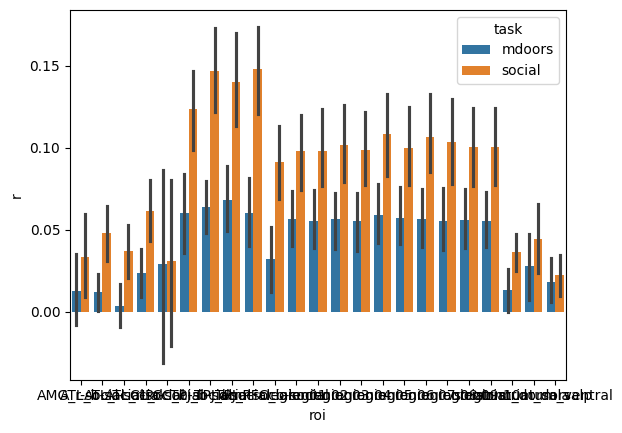

In [39]:
sns.barplot(x='roi',y='r',hue='task', data=all_sub_sim_val_win)

<Axes: xlabel='roi', ylabel='r'>

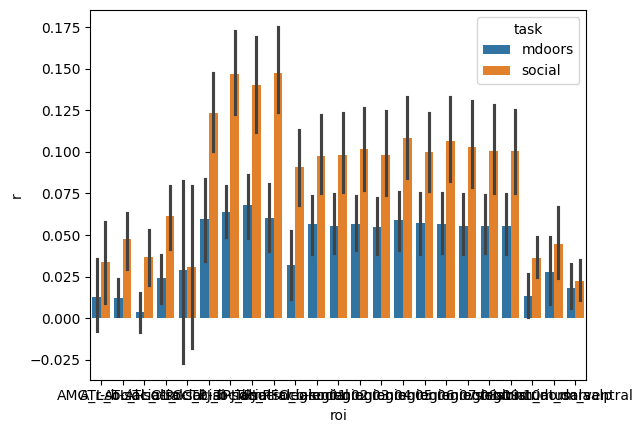

In [40]:
sns.barplot(x='roi',y='r',hue='task', data=all_sub_sim_val_win)
#sns.stripplot(x='roi',y='r',hue='task', data=all_sub_sim_val_win)
